# **Notebook 15 – Before vs After Analysis**

In [27]:
# Load Dataset
import pandas as pd 
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
df = pd.read_csv("hospital_patient_readmission_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        4525 non-null   object 
 1   Age               4479 non-null   float64
 2   Length_of_Stay    4525 non-null   int64  
 3   Number_of_Visits  4525 non-null   int64  
 4   Medication_Count  4480 non-null   float64
 5   Treatment_Cost    4480 non-null   float64
 6   Lab_Test_Count    4525 non-null   int64  
 7   Waiting_Time      4525 non-null   int64  
 8   Recovery_Days     4480 non-null   float64
 9   Admission_Type    4485 non-null   object 
 10  Department        4484 non-null   object 
 11  Insurance_Type    4485 non-null   object 
 12  Diagnosis_Group   4485 non-null   object 
 13  Discharge_Type    4525 non-null   object 
 14  Readmission       4525 non-null   int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 530.4+ KB


In [28]:

numeric_features = df.drop(columns=["Patient_ID", "Readmission"]).select_dtypes(include="number").columns

categorical_features = df.drop(columns=["Patient_ID", "Readmission"]).select_dtypes(include="object").columns


numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                             ("scaler", StandardScaler())])

categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                 ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_features),
                                  ("cat", categorical_pipeline, categorical_features)])

In [29]:
# features and target
X = df.drop(columns=["Patient_ID", "Readmission"])
y = df["Readmission"]

## **1. Shape**



**Understand the Concept**

- Shape shows the number of rows and columns in the dataset.
- Comparing the shape before and after preprocessing shows how preprocessing affects the dataset.
- Row count usually remains the same, while the number of columns can increase after encoding.

**Demonstrate the Concept**

**Example:**

- Compare the number of rows and columns before and after preprocessing.

**AI/ML Usage:**

- Helps verify whether preprocessing changed the dataset size or feature count as expected.

In [30]:
# Compare shape before and after preprocessing

print("Before Preprocessing:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])



Before Preprocessing:
Rows: 4525
Columns: 15


In [31]:
# Apply preprocessing
X_processed = preprocessor.fit_transform( df.drop(columns=["Patient_ID", "Readmission"]))

print("\nAfter Preprocessing:")
print("Rows:", X_processed.shape[0])
print("Columns:", X_processed.shape[1])


After Preprocessing:
Rows: 4525
Columns: 33


**Explanation**

- The number of rows remains the same after preprocessing.
- The number of columns may increase because categorical features are converted into multiple encoded features.

## **2. Data Types**



**Understand the Concept**

- Data types show how each feature is stored in the dataset.
- Before preprocessing, the dataset contains numerical and categorical data types.
- After preprocessing, categorical values are converted into numerical features.

**Demonstrate the Concept**

**Example:**

- Compare the data types before and after preprocessing.

**AI/ML Usage:**

- Helps verify that the data is converted into a suitable format for machine learning.

In [32]:
# Before preprocessing
print("Before Preprocessing:")
print(X.dtypes)

# After preprocessing
X_processed = preprocessor.fit_transform(X)

print("\nAfter Preprocessing:")
print("Processed data type:", X_processed.dtype)

Before Preprocessing:
Age                 float64
Length_of_Stay        int64
Number_of_Visits      int64
Medication_Count    float64
Treatment_Cost      float64
Lab_Test_Count        int64
Waiting_Time          int64
Recovery_Days       float64
Admission_Type       object
Department           object
Insurance_Type       object
Diagnosis_Group      object
Discharge_Type       object
dtype: object

After Preprocessing:
Processed data type: float64


**Explanation**

- Before preprocessing, the dataset contains numerical and categorical columns.
- After preprocessing, all features are represented as numerical values.

## **3. Missing Values**



**Understand the Concept**

- Missing values are empty or unavailable values in the dataset.
- Before preprocessing, some numerical and categorical features contain missing values.
- After preprocessing, imputation replaces the missing values.

**Demonstrate the Concept**

**Example:**

- Compare missing values before and after preprocessing.

In [33]:
# Before preprocessing
print("Missing Values Before Preprocessing:")
print(X.isnull().sum().sum())

# After preprocessing
X_processed = preprocessor.fit_transform(X)

print("\nMissing Values After Preprocessing:")
print(np.isnan(X_processed.toarray()).sum() if hasattr(X_processed, "toarray") 
      else np.isnan(X_processed).sum())

Missing Values Before Preprocessing:
342

Missing Values After Preprocessing:
0


**Explanation**

- Missing values are present before preprocessing.
- Imputation fills the missing values.
- After preprocessing, the processed data contains no missing values.

## **4. Duplicates**



**Understand the Concept**

- Duplicate records are repeated rows in a dataset.
- Duplicates can affect analysis and model training.
- Preprocessing pipelines do not automatically remove duplicates.

**Demonstrate the Concept**

**Example:**

- Compare duplicate records before and after preprocessing.

In [34]:
# Before preprocessing
duplicates_before = X.duplicated().sum()

# Remove duplicates
X_no_duplicates = X.drop_duplicates()

# Apply preprocessing
X_after = preprocessor.fit_transform(X_no_duplicates)

print("Duplicates Before Preprocessing:", duplicates_before)
print("Duplicates After Removing Duplicates:", X_no_duplicates.duplicated().sum())

Duplicates Before Preprocessing: 25
Duplicates After Removing Duplicates: 0


**Explanation**

- Duplicate records are identified before preprocessing.
- Duplicate rows are removed before applying the preprocessing pipeline.
- The preprocessing pipeline itself does not remove duplicates.

## **5. Outliers**



**Understand the Concept**

- Outliers are unusually high or low values in numerical features.
- Preprocessing does not automatically remove outliers.
- Scaling changes the range of the values but does not remove the outliers.

**Demonstrate the Concept**

**Example:**

- Compare outliers in `Treatment_Cost` before and after scaling.

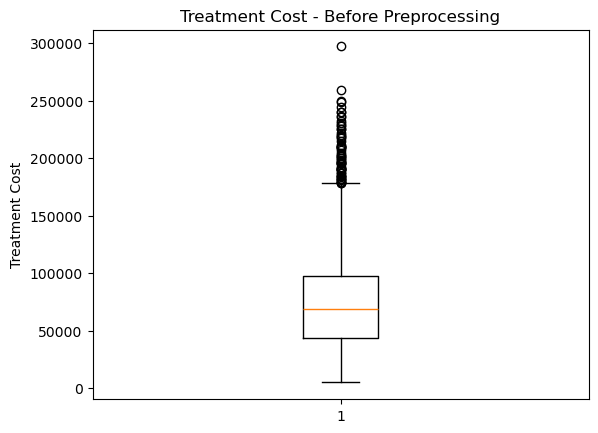

In [35]:
import matplotlib.pyplot as plt

# Before preprocessing
plt.boxplot(X["Treatment_Cost"].dropna())
plt.title("Treatment Cost - Before Preprocessing")
plt.ylabel("Treatment Cost")
plt.show()



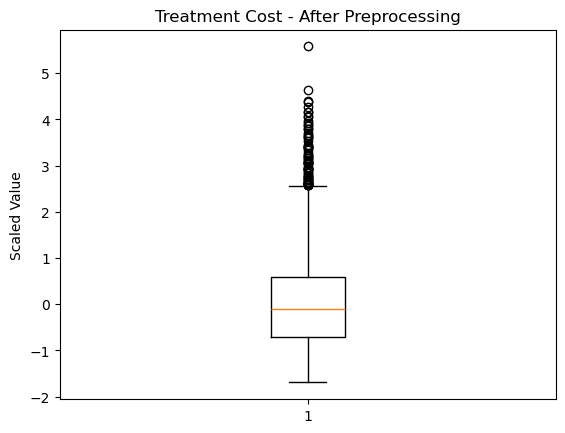

In [36]:
# After preprocessing
treatment_cost_index = list(numeric_features).index("Treatment_Cost")

X_processed = preprocessor.fit_transform(X)
if hasattr(X_processed, "toarray"):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

plt.boxplot(X_dense[:, treatment_cost_index])
plt.title("Treatment Cost - After Preprocessing")
plt.ylabel("Scaled Value")
plt.show()

**Explanation**

- Outliers can be seen in the original `Treatment_Cost` values.
- StandardScaler changes the scale but does not remove the outliers.
- The extreme observations remain present after preprocessing.

## **6. Distributions**



**Understand the Concept**

- A distribution shows how the values of a feature are spread.
- Scaling changes the numerical range but generally preserves the overall distribution shape.
- Comparing histograms helps visualize the effect of preprocessing.

**Demonstrate the Concept**

**Example:**

- Compare the distribution of `Treatment_Cost` before and after scaling.

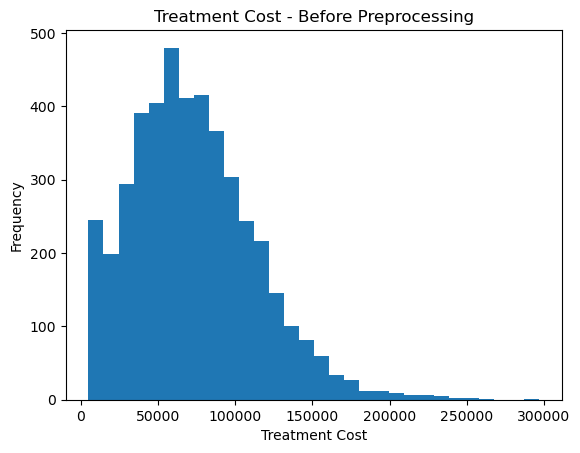

In [37]:
# Before preprocessing
plt.hist(X["Treatment_Cost"].dropna(), bins=30)
plt.title("Treatment Cost - Before Preprocessing")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()



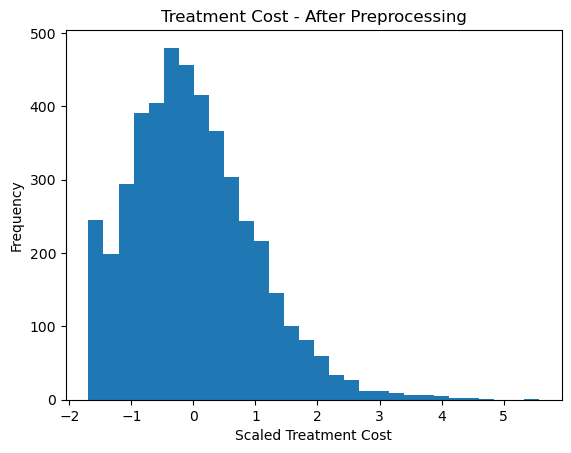

In [38]:
# After preprocessing
treatment_cost_index = list(numeric_features).index("Treatment_Cost")

X_processed = preprocessor.fit_transform(X)

if hasattr(X_processed, "toarray"):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

plt.hist(X_dense[:, treatment_cost_index], bins=30)
plt.title("Treatment Cost - After Preprocessing")
plt.xlabel("Scaled Treatment Cost")
plt.ylabel("Frequency")
plt.show()

**Explanation**

- Before preprocessing, `Treatment_Cost` is shown in its original range.
- After preprocessing, the values are standardized.
- The distribution shape remains generally similar while the numerical scale changes.

## **7. Categorical Values**



**Understand the Concept**

- Categorical features contain values such as department or admission type.
- Before preprocessing, categories are stored as text.
- After preprocessing, one-hot encoding converts categories into numerical columns.

**Demonstrate the Concept**

**Example:**

- Compare `Department` before and after preprocessing.

In [39]:
# Before preprocessing
print("Department Before Preprocessing:")
print(X["Department"].value_counts(dropna=False))

# After preprocessing
X_processed = preprocessor.fit_transform(X)

print("\nNumber of Features After Encoding:")
print(X_processed.shape[1])

Department Before Preprocessing:
Department
General Medicine    658
Oncology            656
Pulmonology         650
Cardiology          640
Orthopedics         628
Neurology           626
Pediatrics          626
NaN                  41
Name: count, dtype: int64

Number of Features After Encoding:
33


**Explanation**

- Before preprocessing, `Department` contains categorical text values.
- After preprocessing, these categories are converted into numerical encoded features.
- One categorical column can become multiple columns.

## **8. Numerical Ranges**



**Understand the Concept**

- Numerical features can have very different ranges before preprocessing.
- StandardScaler transforms numerical features to a common scale.
- Comparing the ranges shows the effect of scaling.

**Demonstrate the Concept**

**Example:**

- Compare `Age` and `Treatment_Cost` ranges before and after preprocessing.

In [40]:
# Before preprocessing
print("Before Preprocessing:")

print("Age Range:",X["Age"].min(),"to", X["Age"].max())

print("Treatment Cost Range:", X["Treatment_Cost"].min(),"to", X["Treatment_Cost"].max())

Before Preprocessing:
Age Range: 18.0 to 85.0
Treatment Cost Range: 5000.0 to 297005.0


In [41]:
# After preprocessing
X_processed = preprocessor.fit_transform(X)

if hasattr(X_processed, "toarray"):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

age_index = list(numeric_features).index("Age")
cost_index = list(numeric_features).index("Treatment_Cost")

print("\nAfter Preprocessing:")

print("Age Range:", X_dense[:, age_index].min(),"to",X_dense[:, age_index].max())

print("Treatment Cost Range:", X_dense[:, cost_index].min(), "to", X_dense[:, cost_index].max())


After Preprocessing:
Age Range: -1.7204900232395475 to 1.7111969910346525
Treatment Cost Range: -1.6919131427338474 to 5.576274102588668


**Explanation**

- Before preprocessing, numerical features have different ranges.
- After StandardScaler, the numerical features are placed on a standardized scale.
- This makes numerical features more comparable for scale-sensitive algorithms.

## **9. Feature Count**



**Understand the Concept**

- Feature count represents the number of input features available to the model.
- Numerical features generally keep one column after preprocessing.
- Categorical features can create multiple columns after one-hot encoding.

**Demonstrate the Concept**

**Example:**

- Compare the number of features before and after preprocessing.

In [42]:
# Before preprocessing
print("Features Before Preprocessing:", X.shape[1])

# After preprocessing
X_processed = preprocessor.fit_transform(X)

print("Features After Preprocessing:", X_processed.shape[1])

Features Before Preprocessing: 13
Features After Preprocessing: 33


**Explanation**

- Before preprocessing, each original feature is represented by one column.
- After preprocessing, categorical features may become multiple encoded columns.
- Therefore, the total feature count can increase after preprocessing.